# Breast Cancer Wisconsin — Model Building

We train and compare 7 classification models, run cross-validation, plot ROC curves, and tune the best performer with `GridSearchCV`.

## 1. Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

import sys
sys.path.append(".")
from utils import (evaluate_model, plot_confusion_matrix, plot_roc_curves,
                   cross_validate_model, compare_models)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = pd.read_csv("data/breast_cancer_cleaned.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (569, 42)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,texture_worst_to_mean,perimeter_worst_to_mean,area_worst_to_mean,smoothness_worst_to_mean,compactness_worst_to_mean,concavity_worst_to_mean,concave_points_worst_to_mean,symmetry_worst_to_mean,fractal_dimension_worst_to_mean,size_composite
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,1.669557,1.503257,2.016983,1.369932,2.397695,2.372209,1.804215,1.902026,1.510609,2209.1720
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,1.317389,1.194883,1.475113,1.460939,2.372838,2.780207,2.650705,1.517660,1.570849,2733.7530
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,1.201412,1.173077,1.420615,1.317518,2.654784,2.281662,1.899922,1.746254,1.459910,2559.7000
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,1.300294,1.274426,1.470344,1.472281,3.051427,2.845485,2.447719,2.556026,1.775452,885.9636
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,1.162483,1.126573,1.214341,1.369890,1.543675,2.020202,1.558006,1.306799,1.305116,2741.1790


## 2. Train / Test Split + Scaling

In [3]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target mean: {y_train.mean():.3f}, Test target mean: {y_test.mean():.3f}")

Train: (455, 41), Test: (114, 41)
Train target mean: 0.374, Test target mean: 0.368


## 3. Model 1 — Logistic Regression


  Logistic Regression
  Accuracy    : 0.9649
  Precision   : 0.9750
  Recall      : 0.9286
  F1 Score    : 0.9512


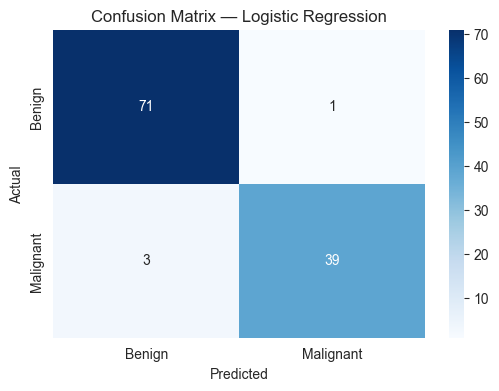

In [4]:
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)

m_lr = evaluate_model("Logistic Regression", y_test, pred_lr)
plot_confusion_matrix(y_test, pred_lr, "Logistic Regression")
plt.show()

## 4. Model 2 — Decision Tree


  Decision Tree
  Accuracy    : 0.9035
  Precision   : 0.9189
  Recall      : 0.8095
  F1 Score    : 0.8608


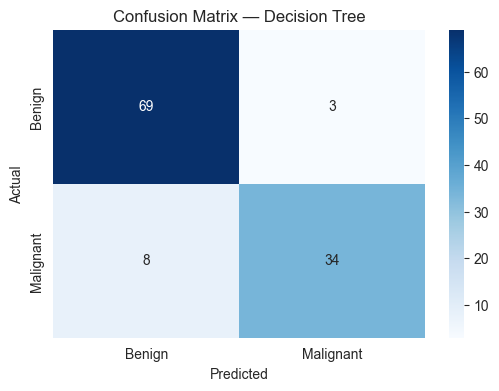

In [5]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

m_dt = evaluate_model("Decision Tree", y_test, pred_dt)
plot_confusion_matrix(y_test, pred_dt, "Decision Tree")
plt.show()

## 5. Model 3 — Random Forest


  Random Forest
  Accuracy    : 0.9649
  Precision   : 1.0000
  Recall      : 0.9048
  F1 Score    : 0.9500


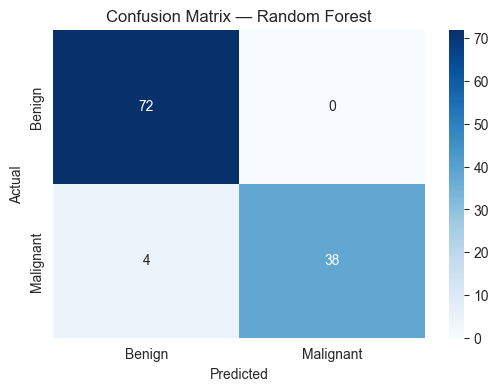

In [6]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

m_rf = evaluate_model("Random Forest", y_test, pred_rf)
plot_confusion_matrix(y_test, pred_rf, "Random Forest")
plt.show()

## 6. Model 4 — KNN (with K optimization)

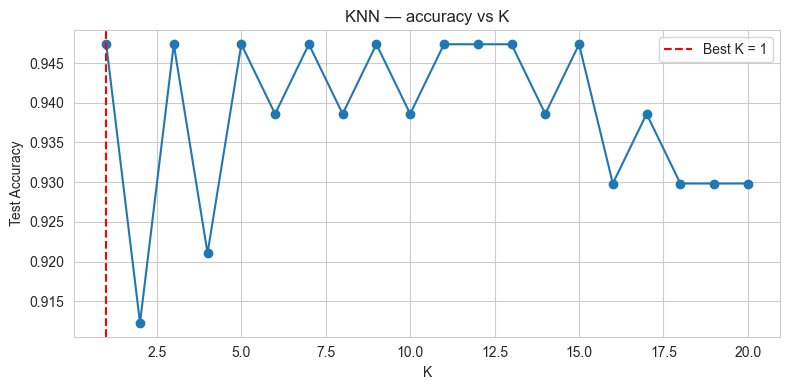


  KNN (K=1)
  Accuracy    : 0.9474
  Precision   : 1.0000
  Recall      : 0.8571
  F1 Score    : 0.9231


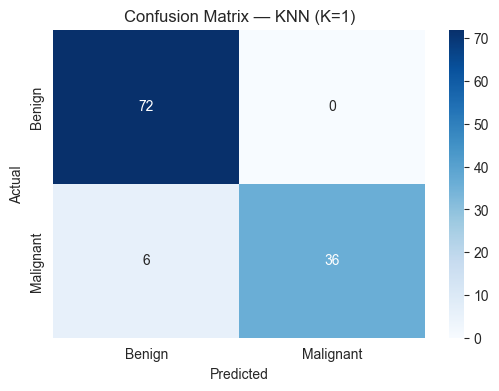

In [7]:
ks = list(range(1, 21))
acc = []
for k in ks:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_s, y_train)
    acc.append(knn_k.score(X_test_s, y_test))

best_k = ks[int(np.argmax(acc))]
plt.figure(figsize=(8, 4))
plt.plot(ks, acc, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.xlabel("K"); plt.ylabel("Test Accuracy")
plt.title("KNN — accuracy vs K")
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
pred_knn = knn.predict(X_test_s)
m_knn = evaluate_model(f"KNN (K={best_k})", y_test, pred_knn)
plot_confusion_matrix(y_test, pred_knn, f"KNN (K={best_k})")
plt.show()

## 7. Model 5 — SVM


  SVM
  Accuracy    : 0.9649
  Precision   : 0.9750
  Recall      : 0.9286
  F1 Score    : 0.9512


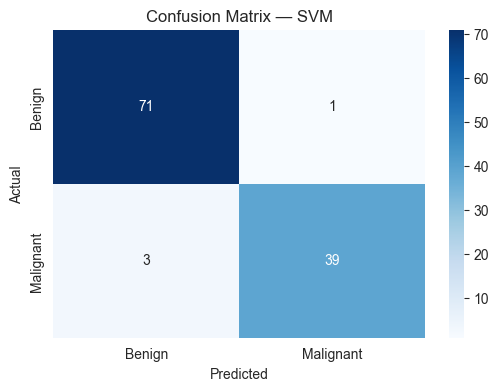

In [8]:
svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(X_train_s, y_train)
pred_svm = svm.predict(X_test_s)

m_svm = evaluate_model("SVM", y_test, pred_svm)
plot_confusion_matrix(y_test, pred_svm, "SVM")
plt.show()

## 8. Model 6 — Gradient Boosting


  Gradient Boosting
  Accuracy    : 0.9737
  Precision   : 1.0000
  Recall      : 0.9286
  F1 Score    : 0.9630


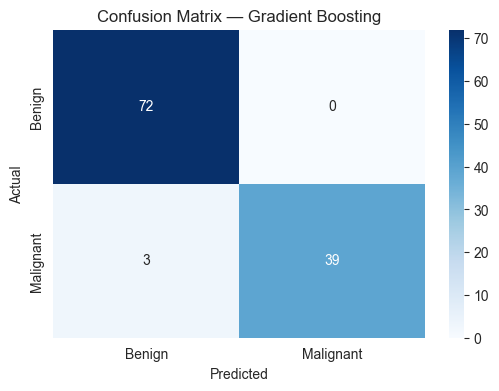

In [9]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

m_gb = evaluate_model("Gradient Boosting", y_test, pred_gb)
plot_confusion_matrix(y_test, pred_gb, "Gradient Boosting")
plt.show()

## 9. Model 7 — Naive Bayes


  Naive Bayes
  Accuracy    : 0.9561
  Precision   : 1.0000
  Recall      : 0.8810
  F1 Score    : 0.9367


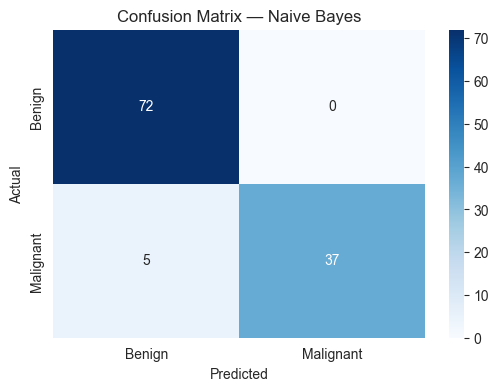

In [10]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)

m_nb = evaluate_model("Naive Bayes", y_test, pred_nb)
plot_confusion_matrix(y_test, pred_nb, "Naive Bayes")
plt.show()

## 10. Feature Importance (tree-based)

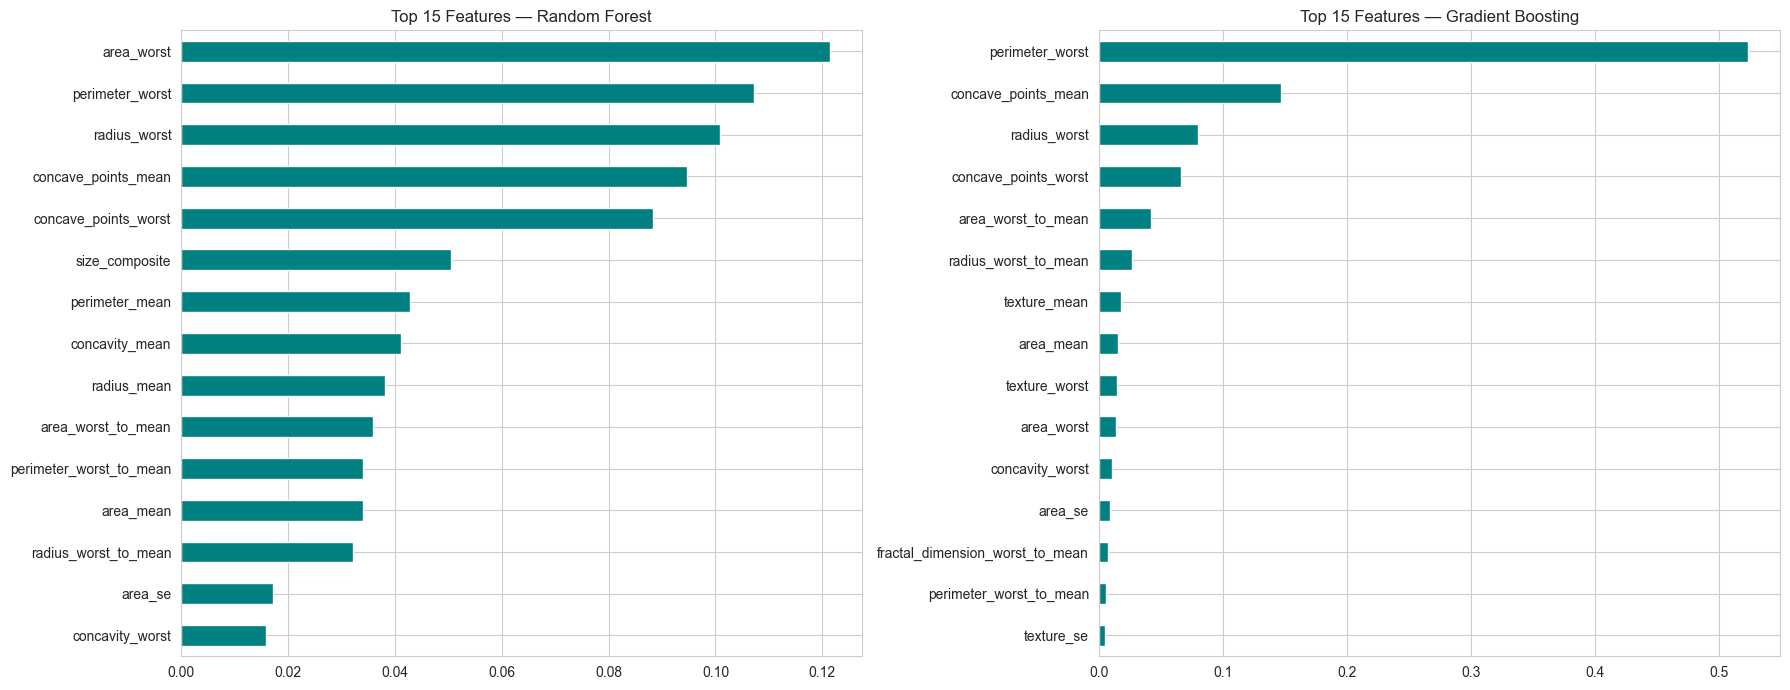

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], gb, "Gradient Boosting")]:
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
    imp.plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Top 15 Features — {name}")
plt.tight_layout(); plt.show()

## 11. Model Comparison

In [12]:
results = [m_lr, m_dt, m_rf, m_knn, m_svm, m_gb, m_nb]
df_results = compare_models(results)
df_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.9737,1.0000,0.9286,0.9630
1,Logistic Regression,0.9649,0.9750,0.9286,0.9512
2,SVM,0.9649,0.9750,0.9286,0.9512
3,Random Forest,0.9649,1.0000,0.9048,0.9500
4,Naive Bayes,0.9561,1.0000,0.8810,0.9367
5,KNN (K=1),0.9474,1.0000,0.8571,0.9231
6,Decision Tree,0.9035,0.9189,0.8095,0.8608


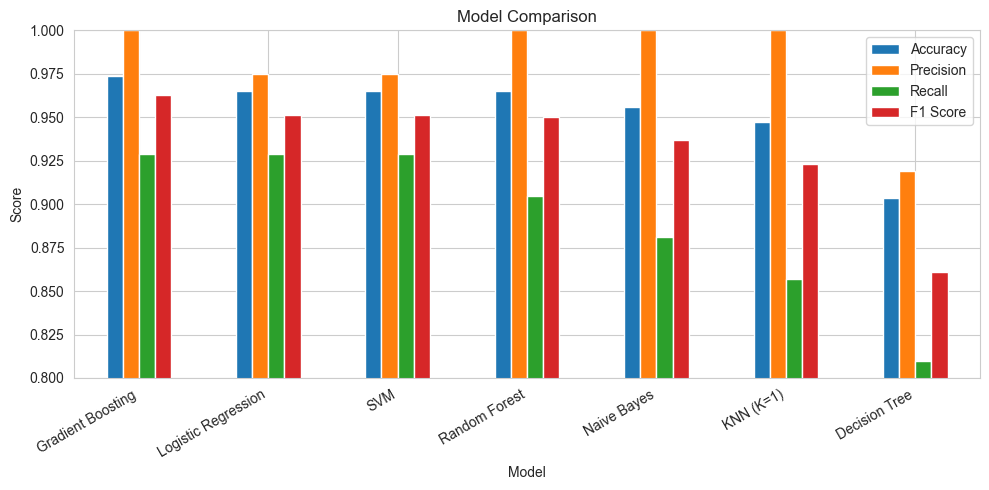

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
df_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", ax=ax)
ax.set_title("Model Comparison")
ax.set_ylim(0.8, 1.0)
ax.set_ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

## 12. 5-Fold Cross-Validation

In [14]:
cv_models = {
    "Logistic Regression": (lr, X_train_s),
    "Decision Tree":       (dt, X_train),
    "Random Forest":       (rf, X_train),
    f"KNN (K={best_k})":   (knn, X_train_s),
    "SVM":                 (svm, X_train_s),
    "Gradient Boosting":   (gb, X_train),
    "Naive Bayes":         (nb, X_train),
}

cv_scores = {}
for name, (m, X_in) in cv_models.items():
    print(f"\n{name}")
    cv_scores[name] = cross_validate_model(m, X_in, y_train, cv=5)


Logistic Regression
  CV F1 Scores : [0.9697 1.     0.9375 0.9697 0.9254]
  Mean F1      : 0.9605 (+/- 0.0264)

Decision Tree
  CV F1 Scores : [0.9394 0.9429 0.8889 0.9275 0.8767]
  Mean F1      : 0.9151 (+/- 0.0271)

Random Forest


  CV F1 Scores : [0.9851 1.     0.9231 0.9697 0.8857]
  Mean F1      : 0.9527 (+/- 0.0423)

KNN (K=1)
  CV F1 Scores : [0.9206 0.9189 0.9206 0.9275 0.9254]
  Mean F1      : 0.9226 (+/- 0.0033)

SVM
  CV F1 Scores : [0.9697 1.     0.9538 0.9412 0.9552]
  Mean F1      : 0.9640 (+/- 0.0201)

Gradient Boosting


  CV F1 Scores : [0.9851 0.9706 0.9231 0.9697 0.9118]
  Mean F1      : 0.9520 (+/- 0.0290)

Naive Bayes
  CV F1 Scores : [0.9394 1.     0.9062 0.8955 0.9118]
  Mean F1      : 0.9306 (+/- 0.0376)


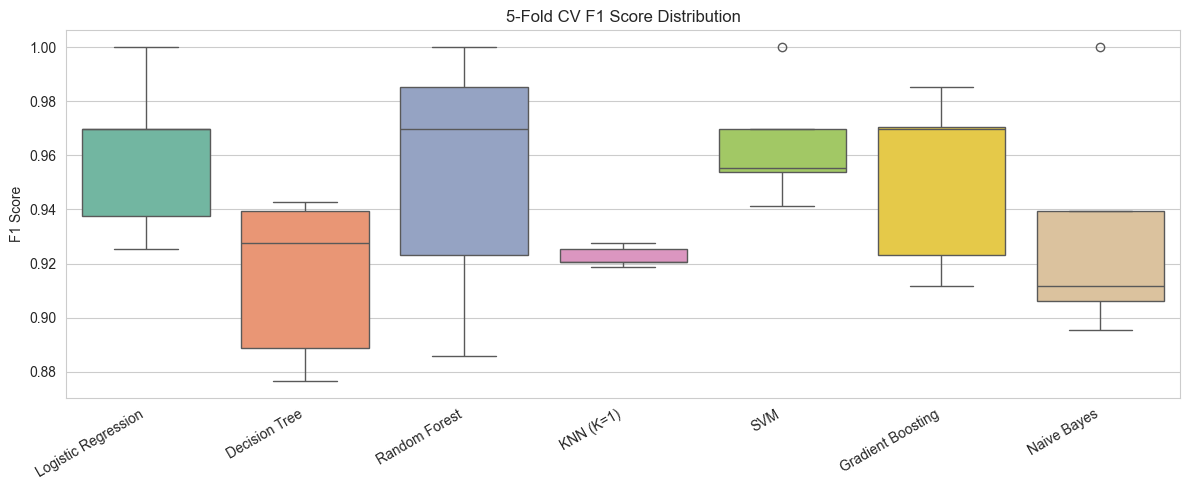

In [15]:
cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize=(12, 5))
sns.boxplot(data=cv_df, palette="Set2")
plt.title("5-Fold CV F1 Score Distribution")
plt.xticks(rotation=30, ha="right"); plt.ylabel("F1 Score")
plt.tight_layout(); plt.show()

## 13. ROC Curves

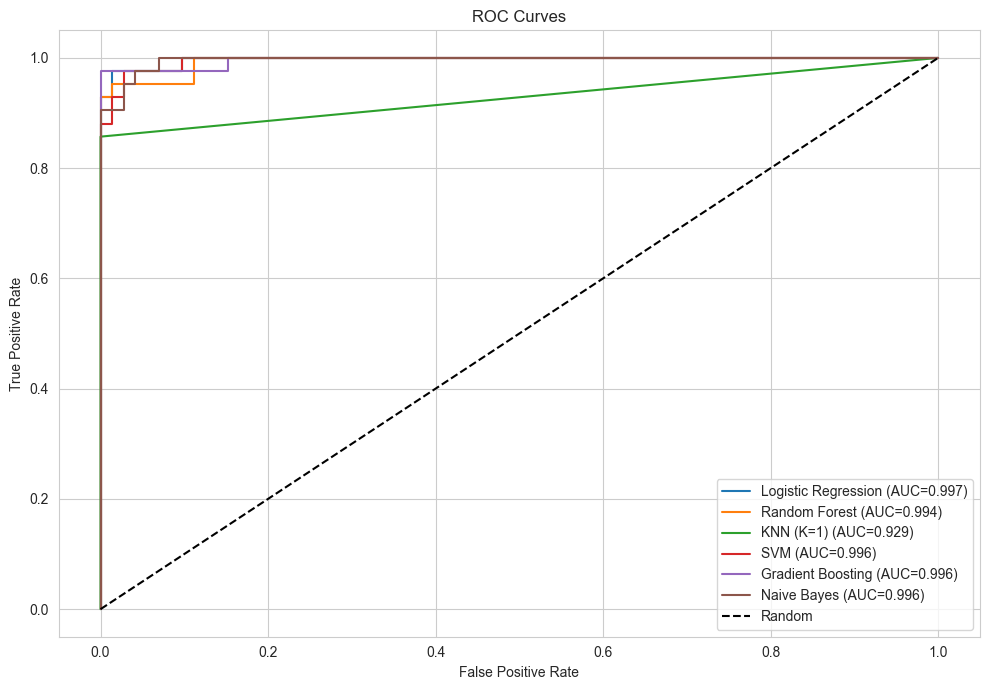

In [16]:
models_for_roc = {
    "Logistic Regression": lr,
    "Random Forest":       rf,
    f"KNN (K={best_k})":   knn,
    "SVM":                 svm,
    "Gradient Boosting":   gb,
    "Naive Bayes":         nb,
}

# Each model needs the input scaled the way it was trained on
fig = plt.figure(figsize=(10, 7))
from sklearn.metrics import roc_curve, auc
for name, m in models_for_roc.items():
    X_in = X_test_s if name in {"Logistic Regression", f"KNN (K={best_k})", "SVM"} else X_test
    if hasattr(m, "predict_proba"):
        y_prob = m.predict_proba(X_in)[:, 1]
    else:
        y_prob = m.decision_function(X_in)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 14. Hyperparameter Tuning — Random Forest

In [17]:
param_grid = {
    "n_estimators":      [100, 200, 400],
    "max_depth":         [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Best params : {grid.best_params_}")
print(f"Best CV F1  : {grid.best_score_:.4f}")

Best params : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1  : 0.9557



  Random Forest (Tuned)
  Accuracy    : 0.9737
  Precision   : 1.0000
  Recall      : 0.9286
  F1 Score    : 0.9630


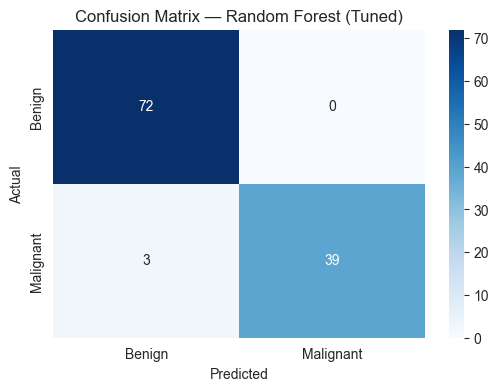

In [18]:
rf_tuned = grid.best_estimator_
pred_rf_t = rf_tuned.predict(X_test)
m_rf_t = evaluate_model("Random Forest (Tuned)", y_test, pred_rf_t)
plot_confusion_matrix(y_test, pred_rf_t, "Random Forest (Tuned)")
plt.show()

## 15. Tuned Feature Importance

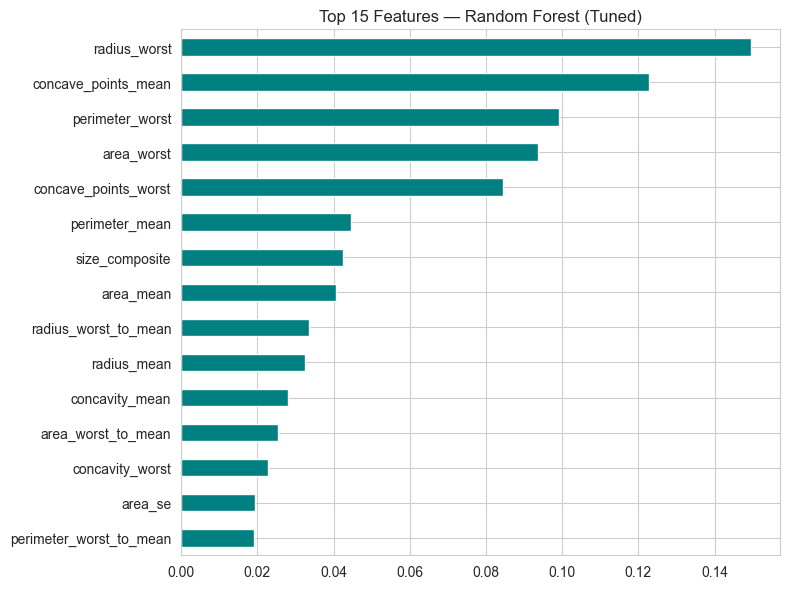

In [19]:
imp = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
plt.figure(figsize=(8, 6))
imp.plot(kind="barh", color="teal")
plt.title("Top 15 Features — Random Forest (Tuned)")
plt.tight_layout(); plt.show()

## 16. Prediction Example

In [20]:
sample = X_test.iloc[[0, 1, 2]]
sample_probs = rf_tuned.predict_proba(sample)
sample_preds = rf_tuned.predict(sample)

for i, (idx, _) in enumerate(sample.iterrows()):
    actual = "Malignant" if y_test.loc[idx] else "Benign"
    pred   = "Malignant" if sample_preds[i] else "Benign"
    print(f"Sample {i}: actual={actual}, predicted={pred}, P(malignant)={sample_probs[i,1]:.3f}")

Sample 0: actual=Benign, predicted=Benign, P(malignant)=0.030
Sample 1: actual=Malignant, predicted=Malignant, P(malignant)=1.000
Sample 2: actual=Benign, predicted=Benign, P(malignant)=0.350


## 17. Final Summary

| Aspect | Result |
|--------|--------|
| Best baseline by F1 | See model comparison above (typically Random Forest / SVM / Gradient Boosting) |
| Tuned model | Random Forest with `GridSearchCV` |
| Top features | `concave_points_worst`, `perimeter_worst`, `radius_worst`, `area_worst`, `concave_points_mean` |
| Class imbalance | Mild (~63/37); handled via `stratify=y` in train_test_split |

### Next Steps
- Try **XGBoost** or **LightGBM** for a stronger boosted baseline.
- Add **SHAP** values for per-prediction explanations (clinical context).
- Deploy as a Streamlit / Gradio app where doctors can upload FNA measurements.
- Investigate calibration of probability outputs — clinical use cases need well-calibrated probabilities.